# RiskOptima 2.x Quick Demos

This notebook highlights the newly refactored core pieces: `MarketData`, `Portfolio`, `FactorRiskModel`, `Constraints`, and `run_backtest`.


## Workflow overview

This notebook is a compact tour of the modular RiskOptima APIs. It introduces market data containers, factor risk modelling, constrained optimization, daily backtesting, and a simple SMA crossover strategy through the package-level interfaces.


In [1]:
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from riskoptima.core import MarketData, Portfolio
from riskoptima.risk import FactorRiskModel
from riskoptima.optim import Constraints, optimize_min_variance
from riskoptima.backtest import run_backtest, SMACrossStrategy
from riskoptima import RiskOptima

warnings.filterwarnings("ignore", category=FutureWarning)

TICKERS = ["AAPL", "MSFT", "KO"]
FACTOR_TICKERS = ["SPY", "QQQ"]
START = "2023-01-01"
END = "2024-01-01"
print(RiskOptima.VERSION)

2.3.5


## 1) MarketData + Portfolio
Build a simple `MarketData` object and a lightweight `Portfolio` definition.


In [3]:
prices = yf.download(TICKERS, start=START, end=END, progress=False, auto_adjust=False)["Close"]
returns = prices.pct_change(fill_method=None).dropna()

market_data = MarketData(prices=prices, returns=returns, calendar="D")

weights = pd.Series([0.4, 0.4, 0.2], index=TICKERS)
benchmark = yf.download("SPY", start=START, end=END, progress=False, auto_adjust=False)["Close"]
portfolio = Portfolio(weights=weights, benchmark=benchmark)

market_data, portfolio


(MarketData(prices=Ticker            AAPL         KO        MSFT
 Date                                         
 2023-01-03  125.070000  62.950001  239.580002
 2023-01-04  126.360001  62.919998  229.100006
 2023-01-05  125.019997  62.200001  222.309998
 2023-01-06  129.619995  63.400002  224.929993
 2023-01-09  130.149994  62.610001  227.119995
 ...                ...        ...         ...
 2023-12-22  193.600006  58.320000  374.579987
 2023-12-26  193.050003  58.560001  374.660004
 2023-12-27  193.149994  58.709999  374.070007
 2023-12-28  193.580002  58.750000  375.279999
 2023-12-29  192.529999  58.930000  376.040009
 
 [250 rows x 3 columns], returns=Ticker          AAPL        KO      MSFT
 Date                                    
 2023-01-04  0.010314 -0.000477 -0.043743
 2023-01-05 -0.010605 -0.011443 -0.029638
 2023-01-06  0.036794  0.019293  0.011785
 2023-01-09  0.004089 -0.012461  0.009736
 2023-01-10  0.004456 -0.007666  0.007617
 ...              ...       ...       ...
 

## 2) FactorRiskModel
Estimate factor exposures and build a covariance matrix.


In [5]:
factor_prices = yf.download(FACTOR_TICKERS, start=START, end=END, progress=False, auto_adjust=False)["Close"]
factor_returns = factor_prices.pct_change(fill_method=None).dropna()

frm = FactorRiskModel(factor_returns=factor_returns).fit(market_data.returns)

frm.exposures.head()


Ticker,QQQ,SPY
AAPL,0.667699,0.264020
KO,-0.512193,0.993381
MSFT,1.646428,-0.879004


## 3) Constraints + Optimization
Use factor-aware constraints with mean-variance optimization.


In [7]:
cov = frm.covariance_matrix()
expected_returns = market_data.returns.mean() * 252

constraints = Constraints(
    weight_bounds=(0.05, 0.7),
    factor_bounds={"SPY": (-0.2, 0.6)}
)

weights_opt = optimize_min_variance(
    cov=cov,
    expected_returns=expected_returns,
    constraints=constraints,
    factor_exposures=frm.exposures
)

weights_opt


Ticker
AAPL    0.172377
KO      0.684673
MSFT    0.142949
dtype: float64

## 4) run_backtest
Run a simple SMA crossover strategy on the same price data.


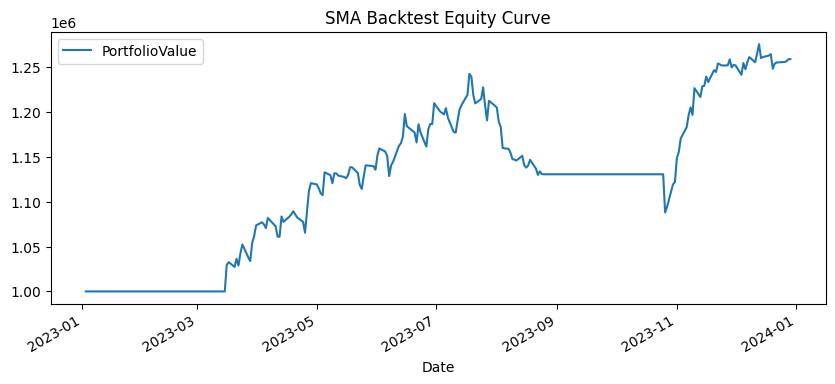

Ticker,AAPL,KO,MSFT
2023-12-22,0.333333,0.333333,0.333333
2023-12-26,0.333333,0.333333,0.333333
2023-12-27,0.333333,0.333333,0.333333
2023-12-28,0.333333,0.333333,0.333333
2023-12-29,0.333333,0.333333,0.333333


In [9]:
strategy = SMACrossStrategy(short_window=20, long_window=50)
equity_curve, weights_history = run_backtest(prices=market_data.prices, strategy=strategy)

equity_curve[["PortfolioValue"]].plot(title="SMA Backtest Equity Curve", figsize=(10, 4))
plt.show()

weights_history.tail()
